In [1]:
import pandas as pd
from pathlib import Path

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'ORCL', 'IBM', 'CRM']
raw_dir = Path("data/raw")
out_dir = Path("data/engineered")
out_dir.mkdir(parents=True, exist_ok=True)

def add_technical_features(df):
    df = df.copy()
    df.set_index("Date", inplace=True)
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
    df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    roll_up = gain.rolling(window=14).mean()
    roll_down = loss.rolling(window=14).mean()
    RS = roll_up / roll_down
    df['RSI_14'] = 100 - (100 / (1 + RS))

    ma20 = df['Close'].rolling(window=20).mean()
    std20 = df['Close'].rolling(window=20).std()
    df['BB_upper'] = ma20 + 2 * std20
    df['BB_lower'] = ma20 - 2 * std20
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['MACD_sig'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['Vol_20'] = df['Close'].rolling(window=20).std()
    df['Vol_50'] = df['Close'].rolling(window=50).std()
    for lag in [1, 2, 3, 5, 10]:
        df[f'lag_{lag}'] = df['Close'].shift(lag)
    df['roll_min_20'] = df['Close'].rolling(20).min()
    df['roll_max_20'] = df['Close'].rolling(20).max()
    df['roll_mean_20'] = df['Close'].rolling(20).mean()
    df['roll_std_20'] = df['Close'].rolling(20).std()

    df.reset_index(inplace=True)
    return df

for ticker in tickers:
    price_path = raw_dir / f"{ticker}_price.csv"
    df = pd.read_csv(price_path, parse_dates=["Date"])
    df = add_technical_features(df)
    df = df.dropna().reset_index(drop=True)
    output_path = out_dir / f"{ticker}_engineered.csv"
    df.to_csv(output_path, index=False)
    print(f"Saved enriched data for {ticker} → {output_path}")

Saved enriched data for AAPL → data/engineered/AAPL_engineered.csv
Saved enriched data for MSFT → data/engineered/MSFT_engineered.csv
Saved enriched data for GOOGL → data/engineered/GOOGL_engineered.csv
Saved enriched data for AMZN → data/engineered/AMZN_engineered.csv
Saved enriched data for META → data/engineered/META_engineered.csv
Saved enriched data for NVDA → data/engineered/NVDA_engineered.csv
Saved enriched data for TSLA → data/engineered/TSLA_engineered.csv
Saved enriched data for ORCL → data/engineered/ORCL_engineered.csv
Saved enriched data for IBM → data/engineered/IBM_engineered.csv
Saved enriched data for CRM → data/engineered/CRM_engineered.csv


In [2]:
engineered_dir = Path("data/engineered")
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)
combined_data = pd.concat([
    pd.read_csv(engineered_dir / f"{ticker}_engineered.csv", parse_dates=["Date"]).assign(Ticker=ticker)
    for ticker in tickers
], ignore_index=True)

combined_data.to_csv(output_dir / "tech_panel_engineered_clean.csv", index=False)
combined_data.to_parquet(output_dir / "tech_panel_engineered_clean.parquet", index=False)

print(combined_data.head())
print(f"\nShape: {combined_data.shape}")
print(f"Tickers included: {combined_data['Ticker'].unique()}")

        Date       Open       High        Low      Close       Volume  \
0 2019-03-14  43.994373  44.042222  43.673806  43.953705   94318000.0   
1 2019-03-15  44.221651  44.814941  43.956106  44.525471  156171600.0   
2 2019-03-18  44.448916  45.068521  44.446522  44.980007  104879200.0   
3 2019-03-19  45.058947  45.212054  44.477616  44.623547  126585600.0   
4 2019-03-20  44.551792  45.331684  44.192947  45.013508  124140800.0   

      SMA_20     SMA_50     EMA_20     EMA_50  ...      lag_1      lag_2  \
0  41.821217  39.493815  41.865322  40.338027  ...  43.470474  43.279076   
1  42.004467  39.631968  42.118670  40.502240  ...  43.953705  43.470474   
2  42.214989  39.854151  42.391178  40.677839  ...  44.525471  43.953705   
3  42.401588  40.040287  42.603785  40.832573  ...  44.980007  44.525471   
4  42.594528  40.235794  42.833282  40.996531  ...  44.623547  44.980007   

       lag_3      lag_5     lag_10  roll_min_20  roll_max_20  roll_mean_20  \
0  42.798237  41.267155  4

In [3]:
# Compare average RSI / Volatility across companies
rsi_vol_summary = combined_data.groupby("Ticker")[["RSI_14", "Vol_20", "Vol_50"]].mean().round(2)
print(rsi_vol_summary)

        RSI_14  Vol_20  Vol_50
Ticker                        
AAPL     55.60    4.38    6.78
AMZN     53.14    4.87    7.47
CRM      52.39    7.93   12.43
GOOGL    54.38    3.46    5.32
IBM      54.40    3.58    5.68
META     54.92   12.00   19.22
MSFT     55.80    7.28   11.21
NVDA     56.40    2.23    3.45
ORCL     53.93    3.07    4.72
TSLA     53.31   13.43   22.03


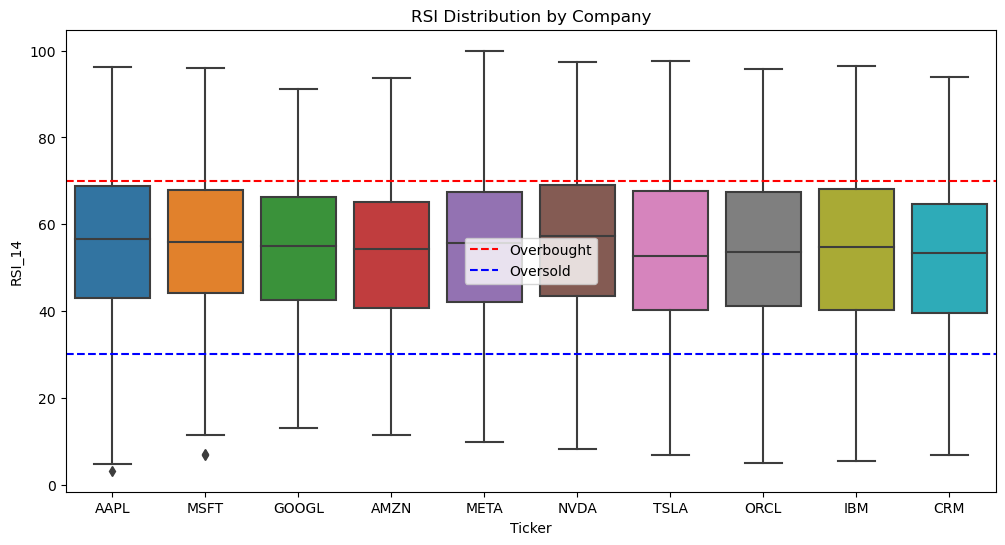

In [4]:
# RSI boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(x="Ticker", y="RSI_14", data=combined_data)
plt.axhline(70, ls='--', color='red', label='Overbought')
plt.axhline(30, ls='--', color='blue', label='Oversold')
plt.title("RSI Distribution by Company")
plt.legend()
plt.show()

In [5]:
# Compare moving average gap (SMA_20 − SMA_50)
combined_data["SMA_gap"] = combined_data["SMA_20"] - combined_data["SMA_50"]
sma_gap_avg = combined_data.groupby("Ticker")["SMA_gap"].mean().round(2)
print(sma_gap_avg)


Ticker
AAPL     1.53
AMZN     1.20
CRM      1.09
GOOGL    1.09
IBM      1.66
META     4.88
MSFT     3.48
NVDA     1.29
ORCL     1.29
TSLA     2.89
Name: SMA_gap, dtype: float64


In [6]:
# Compare momentum indicators (MACD vs signal)
combined_data["MACD_hist"] = combined_data["MACD"] - combined_data["MACD_sig"]
macd_summary = combined_data.groupby("Ticker")["MACD_hist"].mean().round(3)
print(macd_summary)


Ticker
AAPL     0.001
AMZN     0.009
CRM     -0.005
GOOGL    0.003
IBM      0.014
META     0.040
MSFT     0.025
NVDA     0.016
ORCL     0.037
TSLA    -0.004
Name: MACD_hist, dtype: float64
